# Introduction

When processing large datasets of images with Multimodal LLMs, latency can become a bottleneck. In this post, we explore the performance difference between **sequential** processing (one image at a time) and **concurrent/batch** processing (multiple images in parallel) using the Gemini API.

We will use a realistic scenario: counting the number of people in 4 different images representing various crowd densities.


In [19]:
import os
import time
import asyncio
from google import genai
from PIL import Image
import io
import matplotlib.pyplot as plt

# Setup the client
# Ensure GEMINI_API_KEY is set in your environment
client = genai.Client(api_key=os.environ.get("GEMINI_API_KEY"))

MODEL_ID = "models/gemini-3-pro-preview" # Or gemini-1.5-flash

# retina backend
%config InlineBackend.figure_format = 'retina'


# Load the Images

We will use 4 different images:
1. A bus scene (`bus.jpg`)
2. A dense crowd (`crowd1.jpg`)
3. Times Square (`crowd2.jpg`)
4. A classroom (`classroom.jpg`)


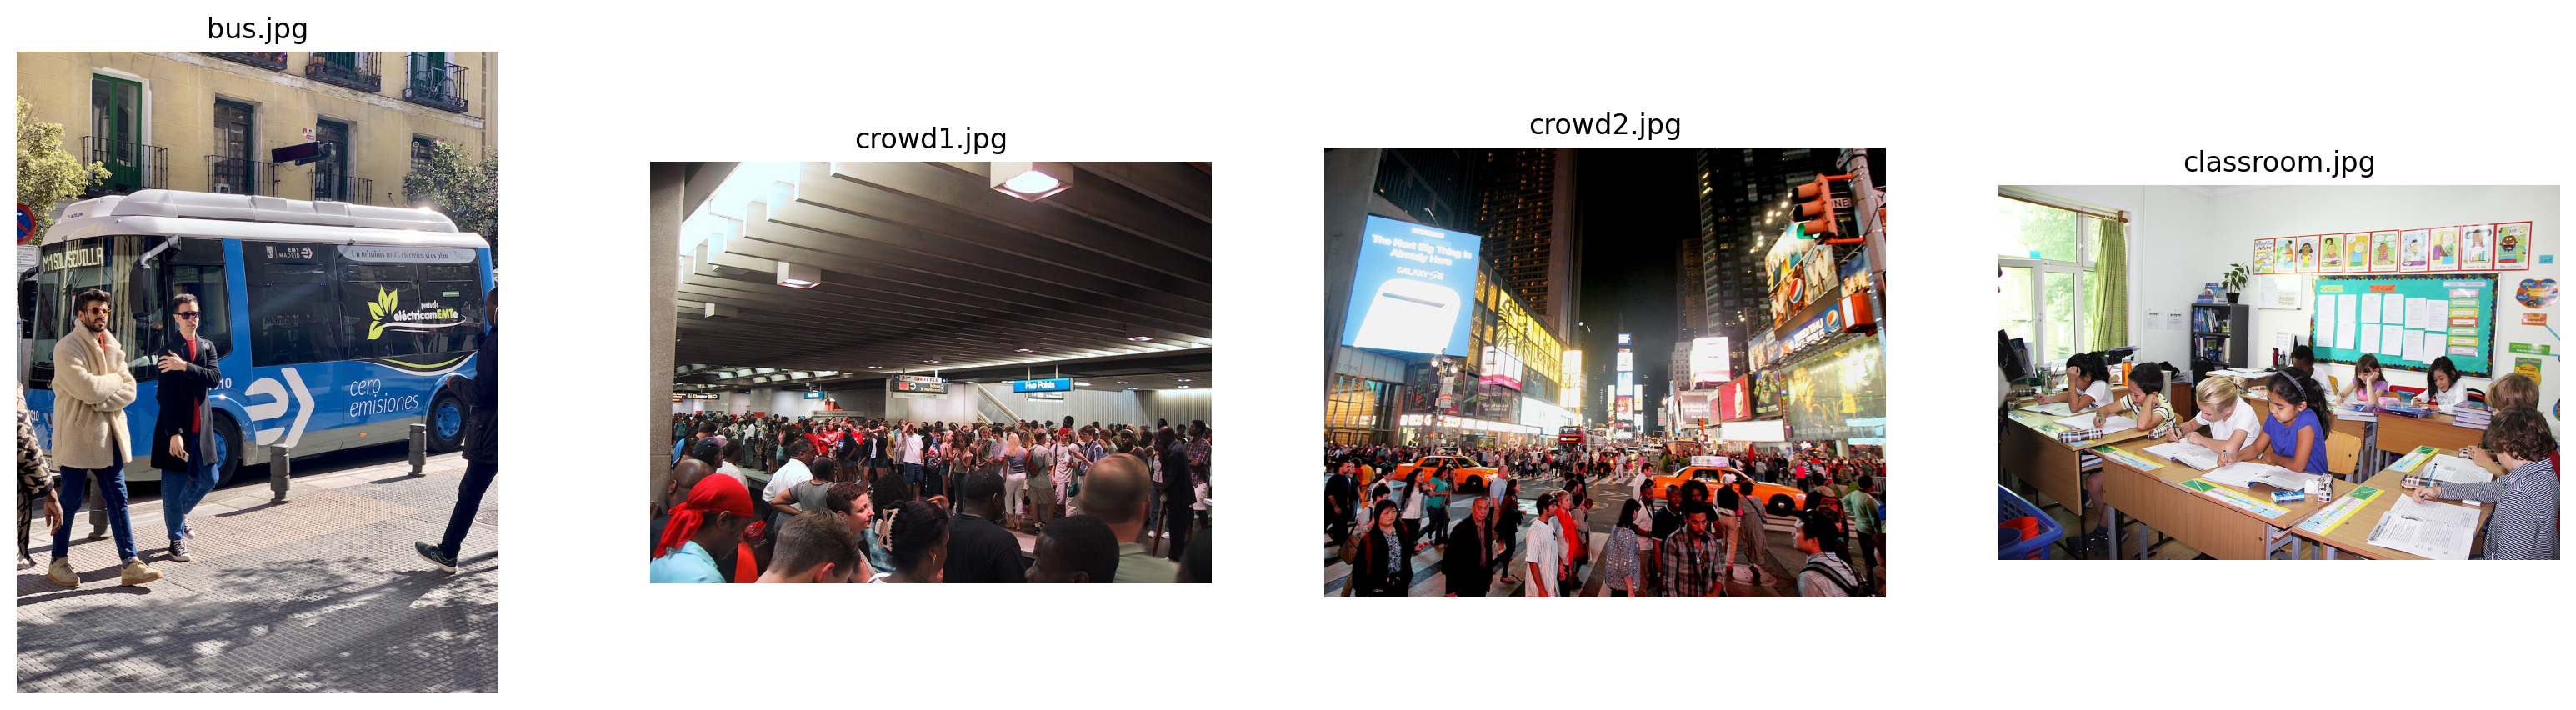

Benchmarking with 4 images.


In [20]:
image_paths = ["bus.jpg", "crowd1.jpg", "crowd2.jpg", "classroom.jpg"]
images = [Image.open(p) for p in image_paths]
prompt = "Count the number of people in this image. Return just the integer number."

# Display images in a grid
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, img, name in zip(axes, images, image_paths):
    ax.imshow(img)
    ax.set_title(name)
    ax.axis('off')
plt.show()

print(f"Benchmarking with {len(images)} images.")


## Sequential Processing

First, let's process the images one by one in a simple loop.


In [15]:
def run_sequential(images, prompt):
    results = []
    start_time = time.time()
    
    for i, img in enumerate(images):
        print(f"Processing image {i+1}/{len(images)}...", end="\n")
        response = client.models.generate_content(
            model=MODEL_ID,
            contents=[img, prompt]
        )
        results.append(response.text)
        
    end_time = time.time()
    return end_time - start_time, results

print("Starting sequential processing...")
seq_time, seq_results = run_sequential(images, prompt)
print(f"Sequential processing took: {seq_time:.2f} seconds")
print(f"Average time per image: {seq_time/len(images):.2f} seconds")

# Print results
for name, res in zip(image_paths, seq_results):
    print(f"{name}: {res}")


Starting sequential processing...
Processing image 1/4...
Processing image 2/4...
Processing image 3/4...
Processing image 4/4...
Sequential processing took: 97.71 seconds
Average time per image: 24.43 seconds
bus.jpg: 6
crowd1.jpg: 102
crowd2.jpg: 144
classroom.jpg: 11


## Batch (Concurrent) Processing

Now, let's use Python's `asyncio` to send multiple requests at the same time.


In [16]:
async def process_one_async(client, img, prompt):
    response = await client.aio.models.generate_content(
        model=MODEL_ID,
        contents=[img, prompt]
    )
    return response.text

async def run_batch(images, prompt):
    start_time = time.time()
    
    # Create tasks for all images
    tasks = [process_one_async(client, img, prompt) for img in images]
    
    # Run them concurrently
    results = await asyncio.gather(*tasks)
    
    end_time = time.time()
    return end_time - start_time, results

print("Starting batch processing...")
# In a Jupyter notebook, await works directly at the top level
batch_time, batch_results = await run_batch(images, prompt)
print(f"Batch processing took: {batch_time:.2f} seconds")
print(f"Average time per image: {batch_time/len(images):.2f} seconds")

# Print results
for name, res in zip(image_paths, batch_results):
    print(f"{name}: {res}")


Starting batch processing...
Batch processing took: 31.35 seconds
Average time per image: 7.84 seconds
bus.jpg: 5
crowd1.jpg: 98 people are visible in the image.
crowd2.jpg: 103
classroom.jpg: 10


## Comparison and Verification

Let's compare the performance and verify that the results are consistent.


Speedup: 3.12x


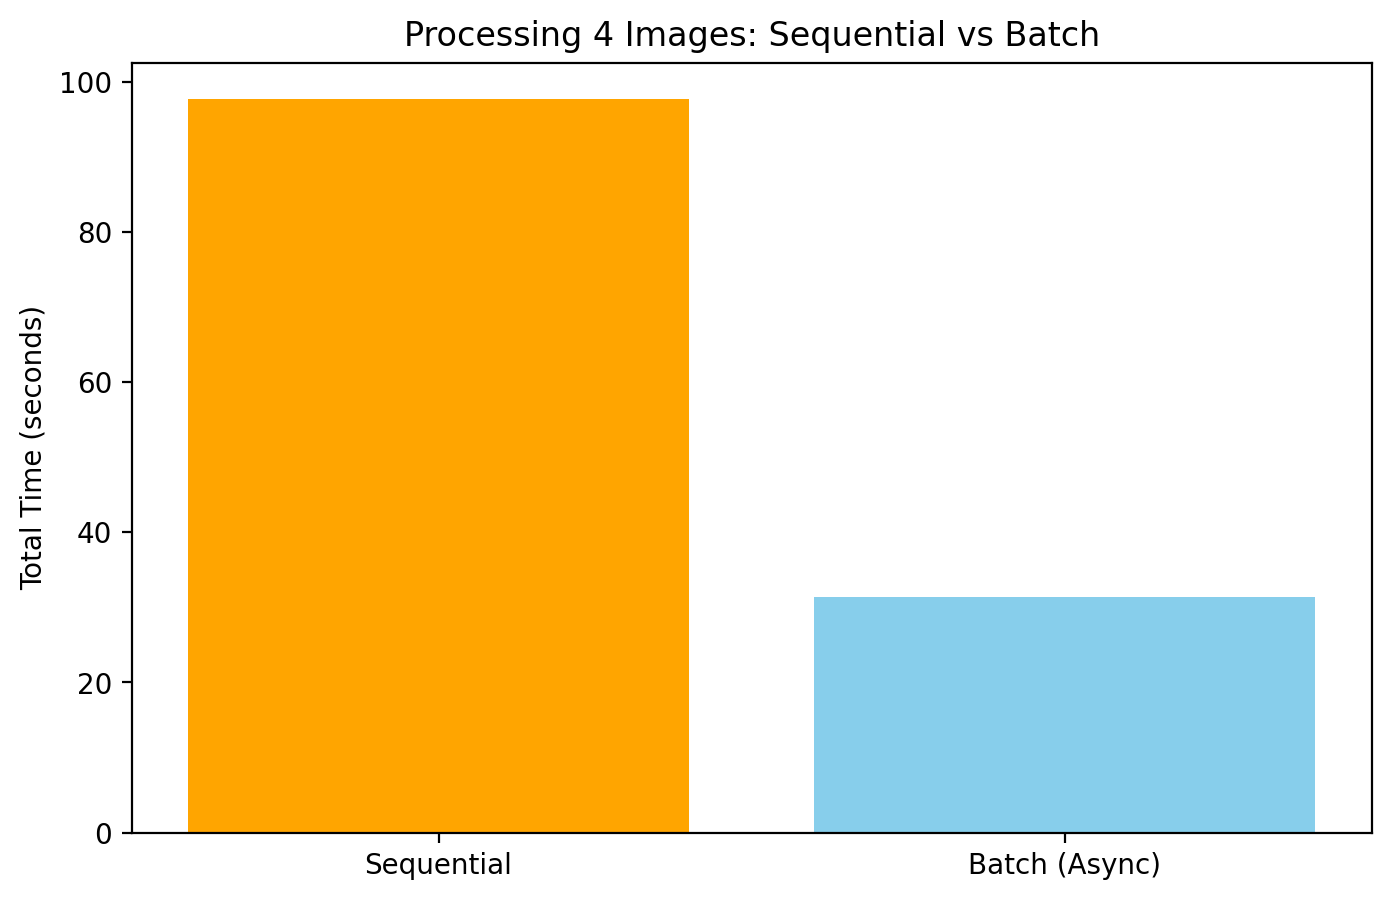

In [21]:
speedup = seq_time / batch_time
print(f"Speedup: {speedup:.2f}x")

# Visualization of speedup
plt.figure(figsize=(8, 5))
plt.bar(['Sequential', 'Batch (Async)'], [seq_time, batch_time], color=['orange', 'skyblue'])
plt.ylabel('Total Time (seconds)')
plt.title(f'Processing {len(images)} Images: Sequential vs Batch')
plt.show()

In [22]:
# Verify consistency
print("Verifying results consistency:")
consistent = True
for i, (s, b) in enumerate(zip(seq_results, batch_results)):
    # Simple check if strings are identical or close (handling potential whitespace)
    s_clean = s.strip()
    b_clean = b.strip()
    match = s_clean == b_clean
    print(f"Image {i+1} ({image_paths[i]}): Sequential='{s_clean}', Batch='{b_clean}' -> Match: {match}")
    if not match:
        consistent = False

if consistent:
    print("SUCCESS: All counts match between sequential and batch processing.")
else:
    print("WARNING: Some counts differ. This might be due to LLM non-determinism.")

Verifying results consistency:
Image 1 (bus.jpg): Sequential='6', Batch='5' -> Match: False
Image 2 (crowd1.jpg): Sequential='102', Batch='98 people are visible in the image.' -> Match: False
Image 3 (crowd2.jpg): Sequential='144', Batch='103' -> Match: False
Image 4 (classroom.jpg): Sequential='11', Batch='10' -> Match: False
